### Modelo de forecasting de demanda SKU 19127
#### Duracell Batteries AA 40pk

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib
import os


# Configuración
SKU = '19127'
NOMBRE_SKU = 'Duracell Batteries AA 40pk'
PAIS = 'Colombia'
DATA_PATH = '../DATA/raw/ventashistoricas_19127.csv'

In [50]:
# Cargar datos
df = pd.read_csv(DATA_PATH)
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# Ver estructura
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Shape: (146516, 8)

Columnas: ['Item_Code', 'Item_Code.1', 'Description', 'Country', 'Cost_Center', 'Transaction_Date', 'Quantity', 'Transaction_Net_USD']

Primeras filas:


,Item_Code,Item_Code.1,Description,Country,Cost_Center,Transaction_Date,Quantity,Transaction_Net_USD
0,19127,19127,Duracell Batteries AA 40pk,Costa Rica,6405,2017-09-01,2.0,28.551099
1,19127,19127,Duracell Batteries AA 40pk,Panamá,6204,2017-09-01,6.0,89.940000
2,19127,19127,Duracell Batteries AA 40pk,El Salvador,6702,2017-09-01,4.0,56.600000
3,19127,19127,Duracell Batteries AA 40pk,Jamaica,8701,2017-09-01,8.0,142.608909
4,19127,19127,Duracell Batteries AA 40pk,Colombia,6105,2017-09-01,11.0,147.051481


In [51]:
#solo Colombia
df = df.dropna(subset=['Quantity'])
df = df[df['Quantity'] > 0]
df = df[df['Country'] == 'Colombia']

print(f"Transacciones de Colombia: {len(df):,}")
print(f"Clubes de Colombia: {df['Cost_Center'].nunique()}")

# Agrupar por fecha (demanda diaria de Colombia)
demanda_diaria = df.groupby('Transaction_Date')['Quantity'].sum().reset_index()
demanda_diaria.columns = ['fecha', 'demanda']
demanda_diaria = demanda_diaria.sort_values('fecha').reset_index(drop=True)

print(f"\nRango de fechas: {demanda_diaria['fecha'].min().date()} a {demanda_diaria['fecha'].max().date()}")
print(f"Total días: {len(demanda_diaria)}")
print(f"\nEstadísticas de demanda diaria Colombia:")
print(demanda_diaria['demanda'].describe())

Transacciones de Colombia: 25,486
Clubes de Colombia: 10

Rango de fechas: 2017-09-01 a 2026-06-18
Total días: 3187

Estadísticas de demanda diaria Colombia:
count    3187.000000
mean       67.990587
std        36.249968
min         7.000000
25%        46.000000
50%        60.000000
75%        79.000000
max       353.000000
Name: demanda, dtype: float64


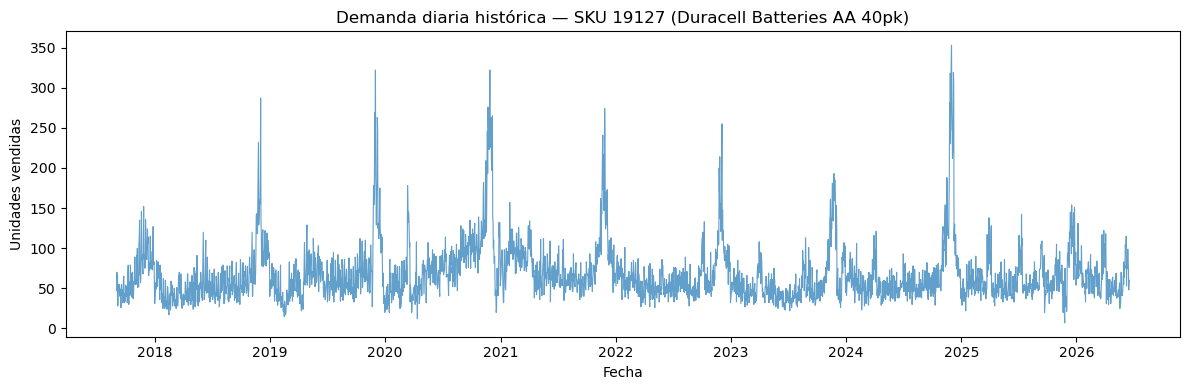

Días sin ventas: 0


In [52]:
# Visualizar la demanda diaria
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(demanda_diaria['fecha'], demanda_diaria['demanda'], 
        linewidth=0.8, color='#1f77b4', alpha=0.7)
ax.set_title(f'Demanda diaria histórica — SKU {SKU} ({NOMBRE_SKU})')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

print("Días sin ventas:", (demanda_diaria['demanda'] == 0).sum())

In [53]:
# Construir features (variables predictoras)
df_model = demanda_diaria.copy()

# Variables de calendario
df_model['dia_semana'] = df_model['fecha'].dt.dayofweek
df_model['mes'] = df_model['fecha'].dt.month
df_model['semana_anio'] = df_model['fecha'].dt.isocalendar().week.astype(int)
df_model['es_finde'] = (df_model['dia_semana'] >= 5).astype(int)

# Lags (demanda de días anteriores)
df_model['lag_7'] = df_model['demanda'].shift(7)
df_model['lag_14'] = df_model['demanda'].shift(14)
df_model['lag_30'] = df_model['demanda'].shift(30)

# Promedios móviles
df_model['media_movil_7'] = df_model['demanda'].shift(1).rolling(7).mean()
df_model['media_movil_30'] = df_model['demanda'].shift(1).rolling(30).mean()

# Eliminar filas con NaN (por los lags)
df_model = df_model.dropna().reset_index(drop=True)

print("Shape después de features:", df_model.shape)
print("\nFeatures creadas:")
print(df_model.columns.tolist())
print("\nPrimeras filas:")
df_model.head()

Shape después de features: (3157, 11)

Features creadas:
['fecha', 'demanda', 'dia_semana', 'mes', 'semana_anio', 'es_finde', 'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30']

Primeras filas:


,fecha,demanda,dia_semana,mes,semana_anio,es_finde,lag_7,lag_14,lag_30,media_movil_7,media_movil_30
0,2017-10-01,46.0,6,10,39,1,65.0,55.0,47.0,43.857143,46.266667
1,2017-10-02,42.0,0,10,40,0,40.0,41.0,70.0,41.142857,46.233333
2,2017-10-03,40.0,1,10,40,0,32.0,48.0,61.0,41.428571,45.300000
3,2017-10-04,52.0,2,10,40,0,43.0,41.0,66.0,42.571429,44.600000
4,2017-10-05,32.0,3,10,40,0,39.0,32.0,28.0,43.857143,44.133333


In [54]:
# Separar features y variable objetivo
FEATURES = ['dia_semana', 'mes', 'semana_anio', 'es_finde', 
            'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30']
TARGET = 'demanda'

X = df_model[FEATURES]
y = df_model[TARGET]

# División temporal: 80% train, 20% test
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

fecha_corte = df_model['fecha'].iloc[split_idx]
print(f"Fecha de corte train/test: {fecha_corte.date()}")
print(f"Train: {len(X_train)} días ({df_model['fecha'].iloc[0].date()} a {df_model['fecha'].iloc[split_idx-1].date()})")
print(f"Test:  {len(X_test)} días ({fecha_corte.date()} a {df_model['fecha'].iloc[-1].date()})")

Fecha de corte train/test: 2024-09-19
Train: 2525 días (2017-10-01 a 2024-09-18)
Test:  632 días (2024-09-19 a 2026-06-18)


In [55]:

def evaluar_modelo(y_true, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{nombre_modelo}")
    print(f"  MAE:  {mae:.2f} unidades")
    print(f"  RMSE: {rmse:.2f} unidades")
    print(f"  MAPE: {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

# Configurar TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

print("Configuración:")
print(f"  Features: {FEATURES}")
print(f"  TimeSeriesSplit: 5 folds")
print(f"  Train total: {len(X_train)} días")
print(f"  Test total:  {len(X_test)} días")

Configuración:
  Features: ['dia_semana', 'mes', 'semana_anio', 'es_finde', 'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30']
  TimeSeriesSplit: 5 folds
  Train total: 2525 días
  Test total:  632 días



Modelo Base (Promedio Móvil 7 días)
  MAE:  16.17 unidades
  RMSE: 24.33 unidades
  MAPE: 25.04%


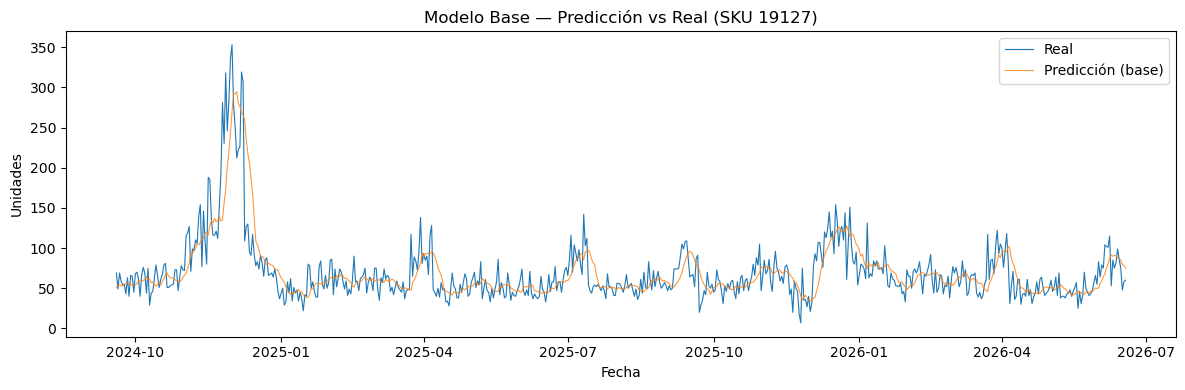

In [56]:
# MODELO 1: Promedio móvil (modelo base)

# Predicción = promedio móvil de los últimos 7 días
y_pred_base = X_test['media_movil_7']

metricas_base = evaluar_modelo(y_test, y_pred_base, "Modelo Base (Promedio Móvil 7 días)")

# Visualizar
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_model['fecha'].iloc[split_idx:], y_test.values, 
        label='Real', linewidth=0.8, color='#1f77b4')
ax.plot(df_model['fecha'].iloc[split_idx:], y_pred_base.values, 
        label='Predicción (base)', linewidth=0.8, 
        color='#ff7f0e', alpha=0.8)
ax.set_title('Modelo Base — Predicción vs Real (SKU 19127)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades')
ax.legend()
plt.tight_layout()
plt.show()

Un MAPE de 25.04% significa que el modelo base se equivoca en promedio un 15%, los otros modelos deben mejorar eso.

In [57]:
# MODELO 2: Random Forest con TimeSeriesSplit

# Evaluar con cross validation temporal
mae_cv = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_cv_train, y_cv_train)
    y_cv_pred = rf.predict(X_cv_val)
    mae_fold = mean_absolute_error(y_cv_val, y_cv_pred)
    mae_cv.append(mae_fold)
    print(f"  Fold {fold+1} MAE: {mae_fold:.2f}")

print(f"\nMAE promedio CV: {np.mean(mae_cv):.2f} (+/- {np.std(mae_cv):.2f})")

# Entrenar modelo final con todo el train
rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)

metricas_rf = evaluar_modelo(y_test, y_pred_rf, "Random Forest")

  Fold 1 MAE: 17.30
  Fold 2 MAE: 22.43
  Fold 3 MAE: 13.74
  Fold 4 MAE: 12.24
  Fold 5 MAE: 13.78

MAE promedio CV: 15.90 (+/- 3.66)

Random Forest
  MAE:  15.61 unidades
  RMSE: 22.45 unidades
  MAPE: 25.05%


Random Forest mejora el MAPE del modelo base (25.04% vs 25.05%)

In [58]:
# MODELO 3: XGBoost con TimeSeriesSplit

# Evaluar con cross validation temporal
mae_cv_xgb = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, 
                       random_state=42, verbosity=0)
    xgb.fit(X_cv_train, y_cv_train)
    y_cv_pred = xgb.predict(X_cv_val)
    mae_fold = mean_absolute_error(y_cv_val, y_cv_pred)
    mae_cv_xgb.append(mae_fold)
    print(f"  Fold {fold+1} MAE: {mae_fold:.2f}")

print(f"\nMAE promedio CV: {np.mean(mae_cv_xgb):.2f} (+/- {np.std(mae_cv_xgb):.2f})")

# Entrenar modelo final con todo el train
xgb_final = XGBRegressor(n_estimators=100, learning_rate=0.1, 
                          random_state=42, verbosity=0)
xgb_final.fit(X_train, y_train)
y_pred_xgb = xgb_final.predict(X_test)

metricas_xgb = evaluar_modelo(y_test, y_pred_xgb, "XGBoost")

  Fold 1 MAE: 17.79
  Fold 2 MAE: 24.07
  Fold 3 MAE: 14.58
  Fold 4 MAE: 12.11
  Fold 5 MAE: 13.17

MAE promedio CV: 16.34 (+/- 4.31)

XGBoost
  MAE:  14.80 unidades
  RMSE: 21.62 unidades
  MAPE: 24.10%


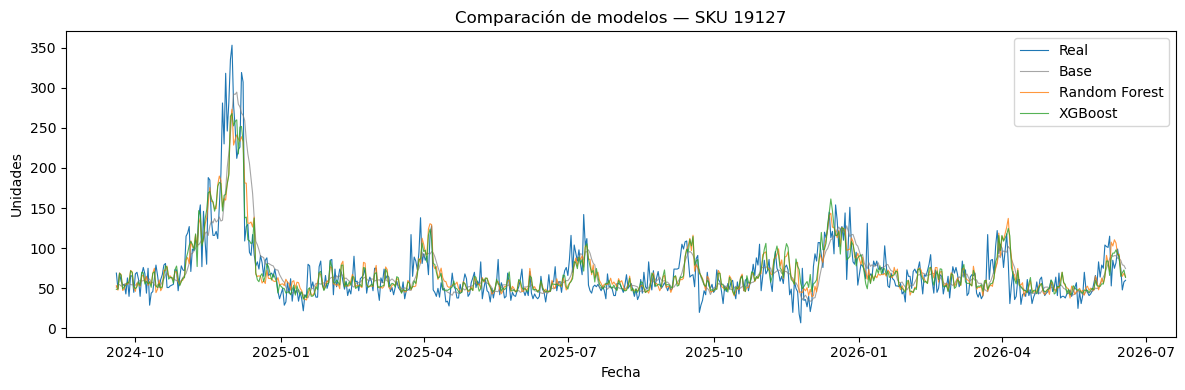

In [59]:
# Comparación visual de los 3 modelos
fig, ax = plt.subplots(figsize=(12, 4))
fechas_test = df_model['fecha'].iloc[split_idx:]

ax.plot(fechas_test, y_test.values, label='Real', 
        linewidth=0.8, color='#1f77b4')
ax.plot(fechas_test, y_pred_base.values, label='Base', 
        linewidth=0.8, color='gray', alpha=0.7)
ax.plot(fechas_test, y_pred_rf, label='Random Forest', 
        linewidth=0.8, color='#ff7f0e', alpha=0.8)
ax.plot(fechas_test, y_pred_xgb, label='XGBoost', 
        linewidth=0.8, color='#2ca02c', alpha=0.8)

ax.set_title('Comparación de modelos — SKU 19127')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades')
ax.legend()
plt.tight_layout()
plt.show()

In [60]:
# GUARDAR EL MEJOR MODELO


# El mejor modelo es XGBoost (menor MAPE)
os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_final, '../models/modelo_19127.pkl')

print("Mejor modelo: XGBoost")
print(f"  MAPE: {metricas_xgb['mape']:.2f}%")
print(f"  MAE:  {metricas_xgb['mae']:.2f} unidades")
print("Modelo guardado en: ../models/modelo_19127.pkl")

Mejor modelo: XGBoost
  MAPE: 24.10%
  MAE:  14.80 unidades
Modelo guardado en: ../models/modelo_19127.pkl


In [61]:
# PREDICCIÓN A 30 DÍAS

# Tomar los últimos 30 días como base para predecir
ultima_fecha = demanda_diaria['fecha'].max()
fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=30)

# Construir features para los próximos 30 días
predicciones = []
historial = demanda_diaria['demanda'].values.tolist()

for fecha in fechas_futuras:
    features = {
        'dia_semana': fecha.dayofweek,
        'mes': fecha.month,
        'semana_anio': fecha.isocalendar()[1],
        'es_finde': int(fecha.dayofweek >= 5),
        'lag_7': historial[-7],
        'lag_14': historial[-14],
        'lag_30': historial[-30],
        'media_movil_7': np.mean(historial[-7:]),
        'media_movil_30': np.mean(historial[-30:]),
    }
    X_pred = pd.DataFrame([features])
    pred = xgb_final.predict(X_pred)[0]
    predicciones.append(pred)
    historial.append(pred)

# Mostrar resultados
forecast_df = pd.DataFrame({
    'fecha': fechas_futuras,
    'demanda_forecast': [round(p) for p in predicciones]
})

print("Forecast próximos 30 días:")
print(forecast_df.to_string(index=False))
print(f"\nDemanda total estimada (30 días): {forecast_df['demanda_forecast'].sum():,} unidades")
print(f"Demanda diaria promedio estimada: {forecast_df['demanda_forecast'].mean():.0f} unidades")

Forecast próximos 30 días:
     fecha  demanda_forecast
2026-06-19                76
2026-06-20                79
2026-06-21                79
2026-06-22                72
2026-06-23                58
2026-06-24                65
2026-06-25                66
2026-06-26                78
2026-06-27                81
2026-06-28                73
2026-06-29                69
2026-06-30                70
2026-07-01                70
2026-07-02                70
2026-07-03                74
2026-07-04                73
2026-07-05                70
2026-07-06                73
2026-07-07                67
2026-07-08                76
2026-07-09                70
2026-07-10                71
2026-07-11                75
2026-07-12                75
2026-07-13                67
2026-07-14                68
2026-07-15                69
2026-07-16                69
2026-07-17                71
2026-07-18                75

Demanda total estimada (30 días): 2,149 unidades
Demanda diaria promedio 

In [62]:

os.makedirs('../models', exist_ok=True)
joblib.dump(xgb_final, '../models/modelo_19127_colombia.pkl')
print("Modelo Colombia guardado: ../models/modelo_19127_colombia.pkl")

Modelo Colombia guardado: ../models/modelo_19127_colombia.pkl


In [ ]:
# Configurar MLflow — cambiar IP cuando el servidor EC2 esté disponible

mlflow.set_tracking_uri("http://3.236.136.151:5000/")
mlflow.set_experiment(f"Forecasting_SKU_{SKU}")

# Modelo base
with mlflow.start_run(run_name="modelo_base_promedio_movil"):
    mlflow.log_param("modelo", "promedio_movil")
    mlflow.log_param("ventana", 7)
    mlflow.log_param("sku", SKU)
    mlflow.log_param("pais", PAIS)
    mlflow.log_metric("mae", metricas_base['mae'])
    mlflow.log_metric("rmse", metricas_base['rmse'])
    mlflow.log_metric("mape", metricas_base['mape'])
    print("✓ Modelo base registrado")

# Random Forest
with mlflow.start_run(run_name="random_forest"):
    mlflow.log_param("modelo", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("sku", SKU)
    mlflow.log_param("pais", PAIS)
    mlflow.log_metric("mae", metricas_rf['mae'])
    mlflow.log_metric("rmse", metricas_rf['rmse'])
    mlflow.log_metric("mape", metricas_rf['mape'])
    print("✓ Random Forest registrado")

# XGBoost
with mlflow.start_run(run_name="xgboost"):
    mlflow.log_param("modelo", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("sku", SKU)
    mlflow.log_param("pais", PAIS)
    mlflow.log_param("mae_cv_promedio", round(np.mean(mae_cv_xgb), 2))
    mlflow.log_metric("mae", metricas_xgb['mae'])
    mlflow.log_metric("rmse", metricas_xgb['rmse'])
    mlflow.log_metric("mape", metricas_xgb['mape'])
    print("✓ XGBoost registrado")

print("\n¡Experimentos registrados en MLflow!")


✓ Modelo base registrado
🏃 View run modelo_base_promedio_movil at: http://44.200.196.170:5000/#/experiments/457371558711010543/runs/ea7f4021c1ab4adf97941646ec99c325
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/457371558711010543
✓ Random Forest registrado
🏃 View run random_forest at: http://44.200.196.170:5000/#/experiments/457371558711010543/runs/71b6b8e5379a48da8c47243c3399dd26
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/457371558711010543
✓ XGBoost registrado
🏃 View run xgboost at: http://44.200.196.170:5000/#/experiments/457371558711010543/runs/8793409567eb4344b3b62ae5c20927e9
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/457371558711010543

¡Experimentos registrados en MLflow!
